# Production Pump-Entry Model — **peak120 @ 0.85**

Squeeze-pump long strategy (`squeeze_pump_v6b`). Everything relevant about the model **currently
running in production**, with all performance figures **computed live** from a fresh 15-month
walk-forward backtest of the live config (no transcribed numbers).

| | |
|---|---|
| **Model** | `results/model_peak120_top10_fdv.json` (50-feature, TOP10 + FDV, BTC-context) |
| **Label** | peak ≥ +120% within an 84h forward window |
| **Entry** | `pred ≥ 0.85` **and** HF V3 hard filter |
| **Exit stack** | `mh72 / stop0.50 / trail0.80-1.00-0.20 / dud48-0.25 / h_exit1.7` |
| **Go-live (prod, thdjpw20)** | **2026-06-17 23:18:30 UTC** (replaced peak150) |
| **md5 (live = backtest)** | `6b1553f3b473325ac8e0f0823dab5038` |

**Backtest source:** `/home/jpei/peak120_prod_wf/` — fresh WF run of `run_label_sweep.py`
(copy with `dud_thr` set to the live **0.25**), peak120@0.85 vs peak150@0.85 anchor, 6 seeds
(42/123/0/7 selection + 2024/555 fresh), HF V3, mark-to-market daily-Sharpe objective, walk-forward
folds over 2025-03 → 2026-06. The harness fits+predicts in a self-consistent btc-mid order
(relative comparison valid). `h_exit` and `liq_cascade` are not modelled in the harness (they apply
≈uniformly and are pure variance-reduction), so reported exits are the 4 priced triggers.

## 1 · Setup — load the deployed model & config

In [1]:
import os, sys, json, hashlib, glob
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import xgboost as xgb

pd.set_option("display.max_rows", 80); pd.set_option("display.width", 170)
plt.rcParams["figure.dpi"] = 110

REPO, V6B = "/home/jpei/longStrategy_new", "/home/jpei/longStrategy_new/squeeze_pump_v6b"
MODEL  = f"{REPO}/results/model_peak120_top10_fdv.json"
CONFIG = f"{V6B}/config.yaml"
WF_DIR = "/home/jpei/peak120_prod_wf"
BARS   = "/opt/data/tardis_1hour_bars"

sys.path.insert(0, V6B)
import core
cfg = core.load_config(CONFIG)
FEATURES = list(cfg.features)
md5 = hashlib.md5(open(MODEL,"rb").read()).hexdigest()
print(f"model md5 : {md5}   (live prod = 6b1553f3b473325ac8e0f0823dab5038)")
print(f"features  : {len(FEATURES)}    threshold: {cfg.entry_threshold}")
print(f"exit      : mh{cfg.max_hold_hours} / stop{cfg.stop_loss_pct} / "
      f"trail{cfg.trigger_return}-{cfg.trail_early_abs}-{cfg.trail_late_abs} / "
      f"dud{cfg.dud_exit_h_check}-{cfg.dud_exit_peak_thr} / h_exit{cfg.h_exit_threshold}")

/usr/local/lib/python3.9/site-packages/xgboost/core.py:265: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc 2.28+) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(


model md5 : 6b1553f3b473325ac8e0f0823dab5038   (live prod = 6b1553f3b473325ac8e0f0823dab5038)
features  : 50    threshold: 0.85
exit      : mh72 / stop0.5 / trail0.8-1.0-0.2 / dud48-0.25 / h_exit1.7


## 2 · Production configuration

Entry is a two-gate decision (XGBoost score ≥ 0.85 **and** the HF V3 hard filter). Exit is a
5-trigger stack; `dud_exit_peak_thr` was raised `0.15 → 0.25` on 2026-06-18 (single-knob Pareto
win) — this backtest uses that live value.

In [2]:
rows = [
 ("Entry","entry_threshold",cfg.entry_threshold,"XGBoost pump-score gate"),
 ("Entry","max_positions",cfg.max_positions,"concurrent open cap"),
 ("Entry","max_units_per_symbol",cfg.max_units_per_symbol,"pyramiding cap / symbol"),
 ("HF V3","oi_coin_3d_chg_pct_min",cfg.oi_coin_3d_chg_pct_min,"raised 30->20 (2026-06-15)"),
 ("HF V3","oi_coin_7d_chg_pct_min",cfg.oi_coin_7d_chg_pct_min,""),
 ("HF V3","total_cvd_7d_min",cfg.total_cvd_7d_min,""),
 ("HF V3","ret_3d_pct_min",cfg.ret_3d_pct_min,""),
 ("Exit","max_hold_hours",cfg.max_hold_hours,"time exit (mh72)"),
 ("Exit","stop_loss_pct",cfg.stop_loss_pct,"hard stop"),
 ("Exit","trail_early_abs",cfg.trail_early_abs,"trail before trigger"),
 ("Exit","trail_late_abs",cfg.trail_late_abs,"trail after trigger"),
 ("Exit","trigger_return",cfg.trigger_return,"arms the late trail"),
 ("Exit","dud_exit_h_check",cfg.dud_exit_h_check,"dud check hour"),
 ("Exit","dud_exit_peak_thr",cfg.dud_exit_peak_thr,"dud peak bar (0.15->0.25)"),
 ("Exit","h_exit_threshold",cfg.h_exit_threshold,"H-value short exit"),
]
print(f"primary_tag {cfg.primary_tag} | perp {cfg.perp_tags} | spot {cfg.spot_tags}")
print(f"excluded symbols: {len(cfg.exclude_symbols)}")
pd.DataFrame(rows, columns=["group","param","value","note"])

primary_tag binance_futures | perp ['binance_futures', 'bybit_perps', 'okex_swap'] | spot ['binance_spot', 'bybit_spot', 'okx_spot', 'bitget_spot']
excluded symbols: 21


,group,param,value,note
0,Entry,entry_threshold,0.85,XGBoost pump-score gate
1,Entry,max_positions,70.00,concurrent open cap
2,Entry,max_units_per_symbol,20.00,pyramiding cap / symbol
3,HF V3,oi_coin_3d_chg_pct_min,20.00,raised 30->20 (2026-06-15)
4,HF V3,oi_coin_7d_chg_pct_min,0.00,
5,HF V3,total_cvd_7d_min,-1000000.00,
6,HF V3,ret_3d_pct_min,0.00,
7,Exit,max_hold_hours,72.00,time exit (mh72)
8,Exit,stop_loss_pct,0.50,hard stop
9,Exit,trail_early_abs,1.00,trail before trigger


## 3 · Model & feature importances

50 features = 25 core + 5 all-spot CVD + 6 FDV + 10 TOP10-augmented + 4 BTC-context.
Gain importances read live from the deployed booster.

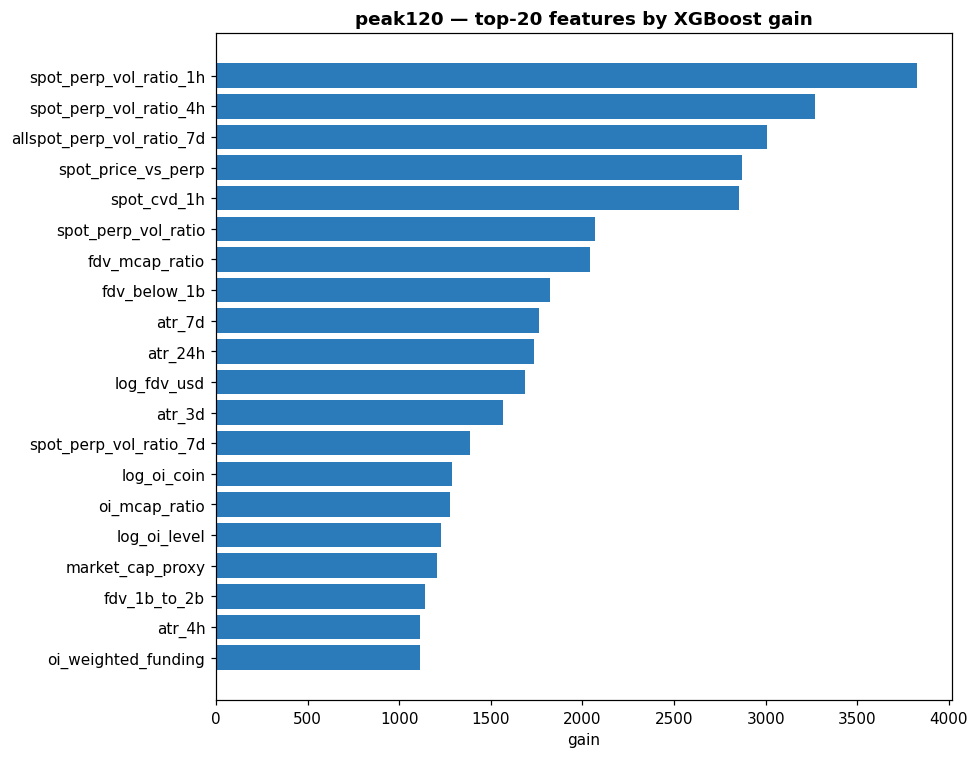

,feature,gain,gain_pct
0,spot_perp_vol_ratio_1h,3825.974121,7.480269
1,spot_perp_vol_ratio_4h,3270.202637,6.393665
2,allspot_perp_vol_ratio_7d,3006.891357,5.878857
3,spot_price_vs_perp,2868.250488,5.607797
4,spot_cvd_1h,2856.544189,5.584910
5,spot_perp_vol_ratio,2068.109863,4.043419
6,fdv_mcap_ratio,2040.988525,3.990394
7,fdv_below_1b,1822.206299,3.562647
8,atr_7d,1761.075562,3.443128
9,atr_24h,1737.959473,3.397933


In [3]:
bst = xgb.Booster(); bst.load_model(MODEL)
gain = bst.get_score(importance_type="gain")
imp = pd.DataFrame([(FEATURES[int(k[1:])], v) for k,v in gain.items()],
                   columns=["feature","gain"]).sort_values("gain", ascending=False).reset_index(drop=True)
imp["gain_pct"] = 100*imp["gain"]/imp["gain"].sum()
top = imp.head(20).iloc[::-1]
fig, ax = plt.subplots(figsize=(9,7))
ax.barh(top["feature"], top["gain"], color="#2b7bba")
ax.set_title("peak120 — top-20 features by XGBoost gain", fontweight="bold"); ax.set_xlabel("gain")
plt.tight_layout(); plt.show()
imp.head(15)

## 4 · Load the fresh walk-forward backtest

`results.csv` (per-seed aggregate rows) and `all_trades.parquet` (the full per-trade ledger).
All analytics below are computed from these. For the **temporal / per-symbol** views (daily trades,
exit mix, hold times, pump capture, price charts) we use a **single representative seed** (chosen
automatically as the seed whose Sharpe is closest to the 6-seed median, printed below) so the figures
read as one realized backtest path; the **multi-seed Sharpe** table (§5) shows robustness.

In [4]:
res = pd.read_csv(f"{WF_DIR}/results.csv")
led = pd.read_parquet(f"{WF_DIR}/all_trades.parquet", engine="fastparquet")
led["entry_ts"] = pd.to_datetime(led["entry_ts"], utc=True)
led["exit_ts"]  = pd.to_datetime(led["exit_ts"],  utc=True)

P120 = led[(led["peak"]==1.2) & (led["thr"]==0.85)].copy()      # all 6 seeds, peak120@0.85
# representative path = the seed whose Sharpe is closest to the 6-seed median (not best, not worst)
_sh = res[(res["peak"]==1.2)&(res["thr"]==0.85)].set_index("seed")["sharpe_d"]
SEED = int((_sh - _sh.median()).abs().idxmin())
t = P120[P120["seed"]==SEED].drop_duplicates(["symbol","entry_ts"]).sort_values("entry_ts").copy()
t["ret"] = t["ret_final"]*100   # %

span_lo, span_hi = P120["entry_ts"].min(), P120["exit_ts"].max()
print(f"WF span        : {span_lo.date()} -> {span_hi.date()}  ({(span_hi-span_lo).days} days)")
print(f"peak120@0.85   : {len(P120)} trades across {P120['seed'].nunique()} seeds")
print(f"seed {SEED} path : {len(t)} trades  ({len(t)/((span_hi-span_lo).days):.2f}/day)")
print(f"exit reasons in ledger: {sorted(led['exit_reason'].unique())}")

WF span        : 2025-08-07 -> 2026-06-21  (318 days)
peak120@0.85   : 2216 trades across 6 seeds
seed 123 path : 376 trades  (1.18/day)
exit reasons in ledger: ['dud_exit', 'stop_loss', 'time_exit', 'trail_stop']


## 5 · Headline performance — Sharpe (peak120 vs peak150 anchor, 6 seeds)

Daily mark-to-market annualized Sharpe per seed, straight from `results.csv`. peak120@0.85 is the
deployed model; peak150@0.85 is the retired prod anchor run in the same harness.

=== peak120@0.85 per-seed ===
        n  trades_per_day  mean_ret_pct  median_ret_pct  win_pct  sharpe_d  maxDD_units  median_hold_h
seed                                                                                                  
42    389           1.219          5.40           -0.74     48.8     1.328        -7.72           48.0
123   376           1.266          9.33            1.07     51.9     2.075        -8.31           48.0
0     362           1.215          8.57            1.07     51.9     2.088        -7.89           48.0
7     377           1.269         10.83            1.38     52.0     2.425        -9.64           48.0
2024  350           1.174          7.07            1.07     52.0     1.755       -11.50           48.0
555   362           1.215          9.20            1.40     52.5     2.127       -11.11           48.0

median Sharpe_d  peak120=2.082  peak150=1.456
peak120 beats peak150 on 5/6 seeds  (median dSharpe +0.530)


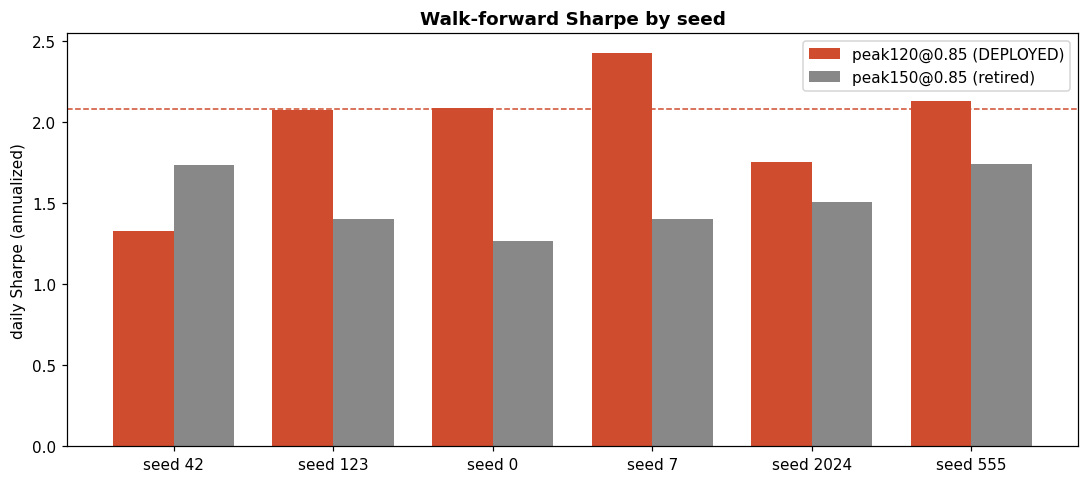

,peak120_sharpe_d,peak150_sharpe_d,dSharpe
seed,,,
42,1.328,1.736,-0.408
123,2.075,1.404,0.671
0,2.088,1.264,0.824
7,2.425,1.403,1.022
2024,1.755,1.508,0.247
555,2.127,1.738,0.389


In [5]:
def seed_tbl(peak):
    g = res[(res["peak"]==peak)&(res["thr"]==0.85)].set_index("seed")
    return g[["n","trades_per_day","mean_ret_pct","median_ret_pct","win_pct","sharpe_d","maxDD_units","median_hold_h"]]
p120, p150 = seed_tbl(1.2), seed_tbl(1.5)
cmp = pd.DataFrame({"peak120_sharpe_d":p120["sharpe_d"], "peak150_sharpe_d":p150["sharpe_d"]})
cmp["dSharpe"] = (cmp["peak120_sharpe_d"]-cmp["peak150_sharpe_d"]).round(3)
print("=== peak120@0.85 per-seed ===");        print(p120.to_string())
print(f"\nmedian Sharpe_d  peak120={p120['sharpe_d'].median():.3f}  peak150={p150['sharpe_d'].median():.3f}")
print(f"peak120 beats peak150 on {(cmp['dSharpe']>0).sum()}/{len(cmp)} seeds  (median dSharpe {cmp['dSharpe'].median():+.3f})")

fig, ax = plt.subplots(figsize=(10,4.5))
x = np.arange(len(cmp)); w=0.38
ax.bar(x-w/2, cmp["peak120_sharpe_d"], w, label="peak120@0.85 (DEPLOYED)", color="#cf4c2e")
ax.bar(x+w/2, cmp["peak150_sharpe_d"], w, label="peak150@0.85 (retired)",  color="#888")
ax.axhline(p120["sharpe_d"].median(), ls="--", lw=1, c="#cf4c2e")
ax.set_xticks(x); ax.set_xticklabels([f"seed {s}" for s in cmp.index])
ax.set_ylabel("daily Sharpe (annualized)"); ax.set_title("Walk-forward Sharpe by seed", fontweight="bold")
ax.legend(); plt.tight_layout(); plt.show()
cmp

## 6 · Trades per day

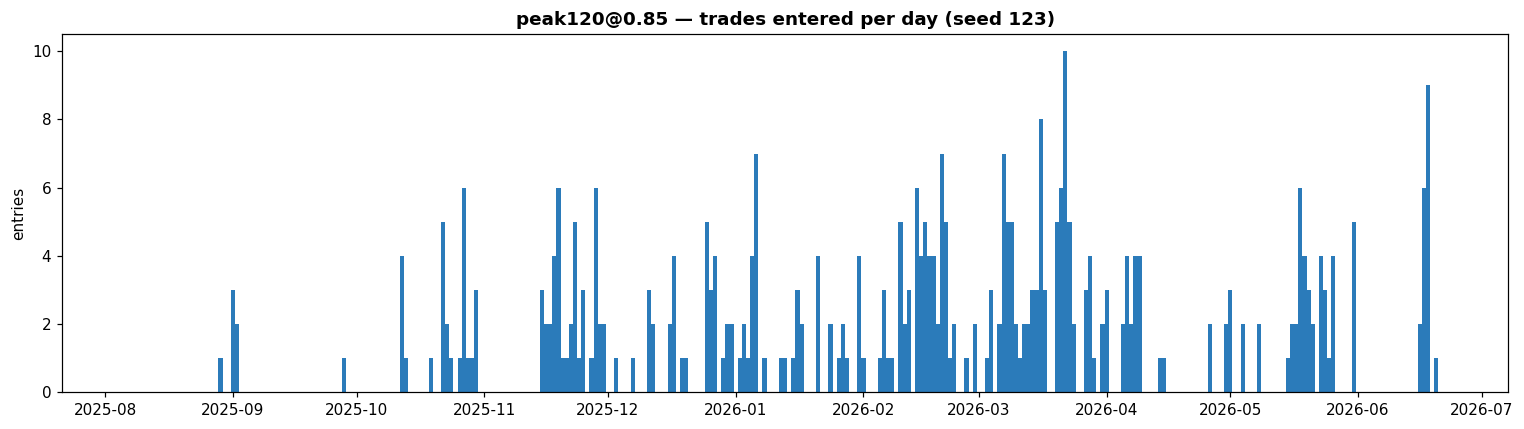

mean 1.18/day | median 0/day | max 10/day | 133 active days of 319 (42%)


In [6]:
daily = t.set_index("entry_ts").resample("1D").size()
daily = daily.reindex(pd.date_range(span_lo.normalize(), span_hi.normalize(), freq="1D", tz="UTC"), fill_value=0)
fig, ax = plt.subplots(figsize=(14,4))
ax.bar(daily.index, daily.values, width=1.0, color="#2b7bba")
ax.set_title(f"peak120@0.85 — trades entered per day (seed {SEED})", fontweight="bold")
ax.set_ylabel("entries"); ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.tight_layout(); plt.show()
print(f"mean {daily.mean():.2f}/day | median {daily.median():.0f}/day | max {daily.max()}/day "
      f"| {(daily>0).sum()} active days of {len(daily)} ({(daily>0).mean()*100:.0f}%)")

## 7 · Exit-condition breakdown

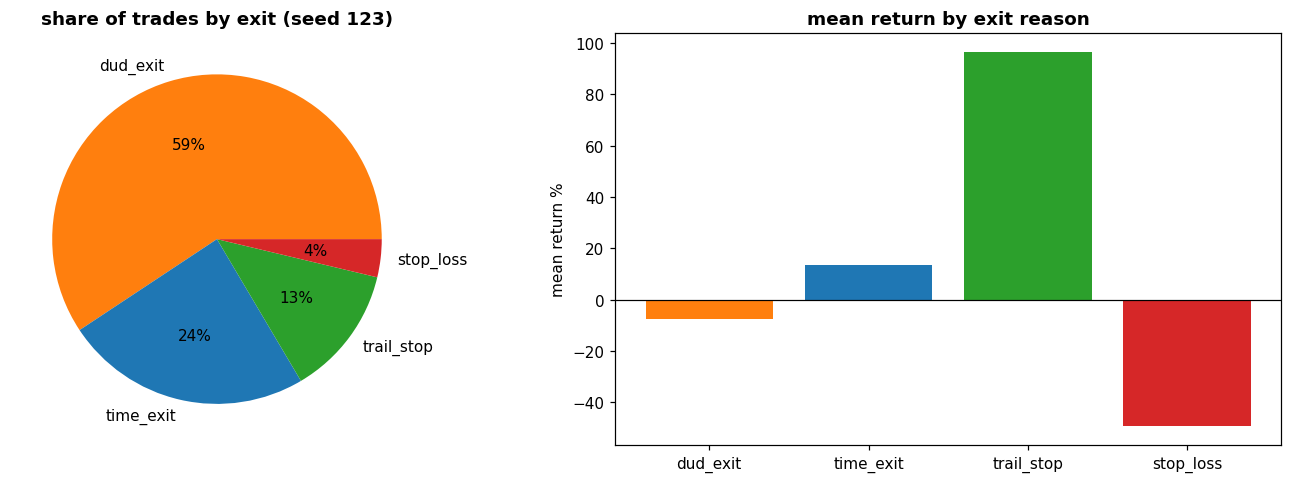

Note: h_exit & liq_cascade not modelled in this harness — these are the 4 priced triggers.


,n,pct,mean_ret,win,med_hold_h
exit_reason,,,,,
dud_exit,223,59.31,-7.35,36.77,48.0
time_exit,91,24.20,13.30,71.43,72.0
trail_stop,48,12.77,96.46,100.00,37.5
stop_loss,14,3.72,-49.34,0.00,33.5


In [7]:
ex = (t.groupby("exit_reason")
        .agg(n=("ret","size"), pct=("ret", lambda s: 100*len(s)/len(t)),
             mean_ret=("ret","mean"), win=("ret", lambda s:100*(s>0).mean()),
             med_hold_h=("exit_hours","median"))
        .sort_values("n", ascending=False).round(2))
fig, (a1,a2) = plt.subplots(1,2, figsize=(13,4.5))
order = ex.index.tolist()
cols = {"trail_stop":"#2ca02c","time_exit":"#1f77b4","dud_exit":"#ff7f0e","stop_loss":"#d62728"}
a1.pie(ex["n"], labels=order, autopct="%1.0f%%", colors=[cols.get(r,"#999") for r in order])
a1.set_title(f"share of trades by exit (seed {SEED})", fontweight="bold")
a2.bar(order, ex["mean_ret"], color=[cols.get(r,"#999") for r in order])
a2.axhline(0, c="k", lw=0.8); a2.set_ylabel("mean return %"); a2.set_title("mean return by exit reason", fontweight="bold")
plt.tight_layout(); plt.show()
print("Note: h_exit & liq_cascade not modelled in this harness — these are the 4 priced triggers.")
ex

## 8 · Holding time

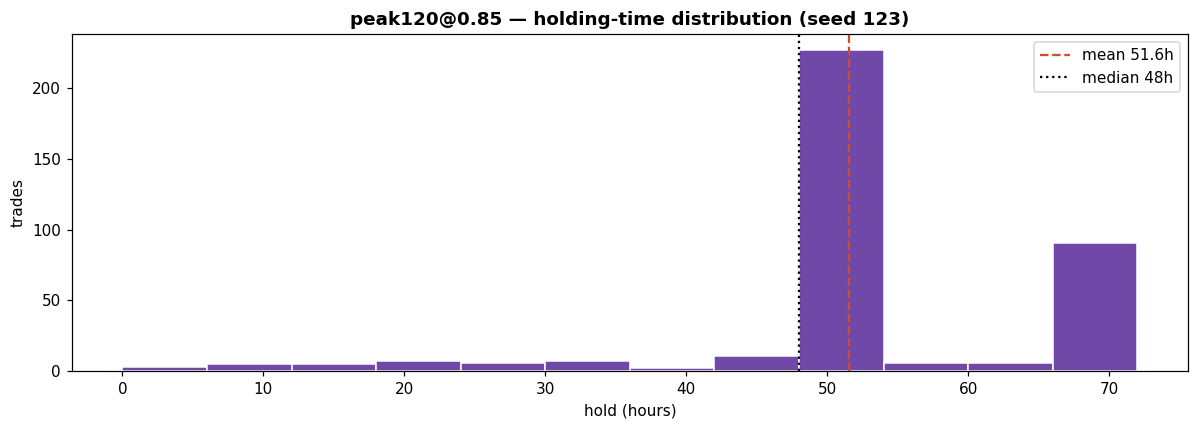

mean 51.6h (2.15d) | median 48h | min 3h | max 72h (= mh72 cap)


,mean,median,count
exit_reason,,,
dud_exit,48.0,48.0,223
stop_loss,32.9,33.5,14
time_exit,71.6,72.0,91
trail_stop,35.5,37.5,48


In [8]:
h = t["exit_hours"]
fig, ax = plt.subplots(figsize=(11,4))
ax.hist(h, bins=range(0, int(h.max())+6, 6), color="#7048a8", edgecolor="white")
ax.axvline(h.mean(), c="#cf4c2e", ls="--", label=f"mean {h.mean():.1f}h")
ax.axvline(h.median(), c="k", ls=":", label=f"median {h.median():.0f}h")
ax.set_xlabel("hold (hours)"); ax.set_ylabel("trades"); ax.legend()
ax.set_title(f"peak120@0.85 — holding-time distribution (seed {SEED})", fontweight="bold")
plt.tight_layout(); plt.show()
print(f"mean {h.mean():.1f}h ({h.mean()/24:.2f}d) | median {h.median():.0f}h | "
      f"min {h.min()}h | max {h.max()}h (= mh72 cap)")
t.groupby("exit_reason")["exit_hours"].agg(["mean","median","count"]).round(1)

## 9 · Pump capture

The pump **label** is purely price-derived: a bar is a pump if its forward-84h max return ≥ +120%.
Consecutive labelled bars are collapsed into one **pump event** (new event after a >48h gap). Over
the backtest span and the binance-futures universe (prod exclude list applied):

- **# pumps** — distinct pump events
- **% captured** — events with ≥1 representative-seed entry during the run-up (entry before the event's peak)
- **% of pump upside captured** — Σ realised return on captured-pump trades ÷ Σ peak-return of all pumps

In [9]:
FWD = 84; GAP = 48
syms = sorted({os.path.basename(f).replace("_binance_futures.parquet","")
               for f in glob.glob(f"{BARS}/*_binance_futures.parquet")})
syms = [s for s in syms if s not in set(cfg.exclude_symbols)]

events = []   # (symbol, start_ts, peak_ts, peak_ret)
for s in syms:
    try:
        df = pd.read_parquet(f"{BARS}/{s}_binance_futures.parquet", engine="fastparquet")
    except Exception:
        continue
    df["ts"] = pd.to_datetime(df["ts"], utc=True)
    df = df.sort_values("ts").drop_duplicates("ts")
    df = df[(df["ts"]>=span_lo) & (df["ts"]<=span_hi)]
    if len(df) < FWD+2: continue
    c = df["close"].to_numpy(); ts = df["ts"].to_numpy()
    n = len(c); fwd_max = np.full(n, np.nan); fwd_arg = np.zeros(n, dtype=int)
    for i in range(n-1):
        j = min(i+1+FWD, n); w = c[i+1:j]
        if len(w): fwd_max[i] = w.max(); fwd_arg[i] = i+1+int(w.argmax())
    pr = fwd_max/c - 1.0
    lab = pr >= 1.2
    i = 0
    while i < n:
        if lab[i]:
            k = i
            while k+1 < n and lab[k+1] and (ts[k+1]-ts[k]) <= np.timedelta64(GAP,"h"):
                k += 1
            seg = slice(i, k+1)
            best = i + int(np.nanargmax(pr[seg]))
            events.append((s, ts[i], ts[fwd_arg[best]], float(pr[best])))
            i = k+1
        else:
            i += 1
ev = pd.DataFrame(events, columns=["symbol","start_ts","peak_ts","peak_ret"])
print(f"universe symbols scanned: {len(syms)}")
print(f"# pump events (>=+120% in 84h) over {span_lo.date()}..{span_hi.date()}: {len(ev)}")

universe symbols scanned: 447
# pump events (>=+120% in 84h) over 2025-08-07..2026-06-21: 563


# pumps                       : 563
# captured (>=1 entry pre-peak): 54  -> 9.6% of pumps captured
Sum of pump UPSIDE (peak_ret) : 103,977%   (theoretical max if perfectly sold at peak)
Realised return on pump-trades: 7,979%  -> 7.7% of pump upside captured
Total realised (all seed-123 trades): 3,510%


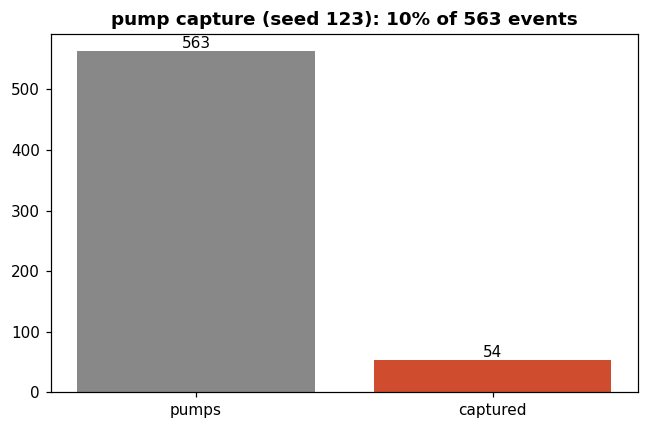

In [10]:
# match representative-seed entries to events: entry within [start-12h, peak_ts] of the same symbol
cap = []
for _, e in ev.iterrows():
    m = t[(t["symbol"]==e.symbol) &
          (t["entry_ts"]>=e.start_ts-pd.Timedelta(hours=12)) &
          (t["entry_ts"]<=e.peak_ts)]
    cap.append((len(m)>0, m["ret_final"].sum()))
ev["captured"] = [c[0] for c in cap]
ev["captured_ret"] = [c[1] for c in cap]

n_pumps = len(ev); n_cap = int(ev["captured"].sum())
pct_cap = 100*n_cap/n_pumps if n_pumps else 0
upside = ev["peak_ret"].sum()
realised = t["ret_final"].sum()                       # total realised on ALL representative-seed trades
realised_pump = ev.loc[ev["captured"],"captured_ret"].sum()
print(f"# pumps                       : {n_pumps}")
print(f"# captured (>=1 entry pre-peak): {n_cap}  -> {pct_cap:.1f}% of pumps captured")
print(f"Sum of pump UPSIDE (peak_ret) : {upside*100:,.0f}%   (theoretical max if perfectly sold at peak)")
print(f"Realised return on pump-trades: {realised_pump*100:,.0f}%  -> {100*realised_pump/upside:.1f}% of pump upside captured")
print(f"Total realised (all seed-{SEED} trades): {realised*100:,.0f}%")
fig, ax = plt.subplots(figsize=(6,4))
ax.bar(["pumps","captured"], [n_pumps, n_cap], color=["#888","#cf4c2e"])
for i,v in enumerate([n_pumps,n_cap]): ax.text(i,v,str(v),ha="center",va="bottom")
ax.set_title(f"pump capture (seed {SEED}): {pct_cap:.0f}% of {n_pumps} events", fontweight="bold")
plt.tight_layout(); plt.show()

## 10 · Buy/sell on price — top-5 and worst-5 symbols

Symbols ranked by **summed realised return** across their representative-seed trades. Green ▲ = entry (buy),
red ▼ = exit (sell), on the hourly close. Window padded ±3 days around each symbol's trades.

TOP-5  : ['EDENUSDT +1125% (n14)', 'BRUSDT +764% (n26)', 'FUSDT +653% (n7)', 'TNSRUSDT +607% (n3)', 'PORTALUSDT +493% (n5)']
WORST-5: ['MAVIAUSDT -314% (n8)', 'UAIUSDT -219% (n12)', 'PTBUSDT -192% (n7)', 'ONUSDT -175% (n6)', 'SQDUSDT -141% (n12)']


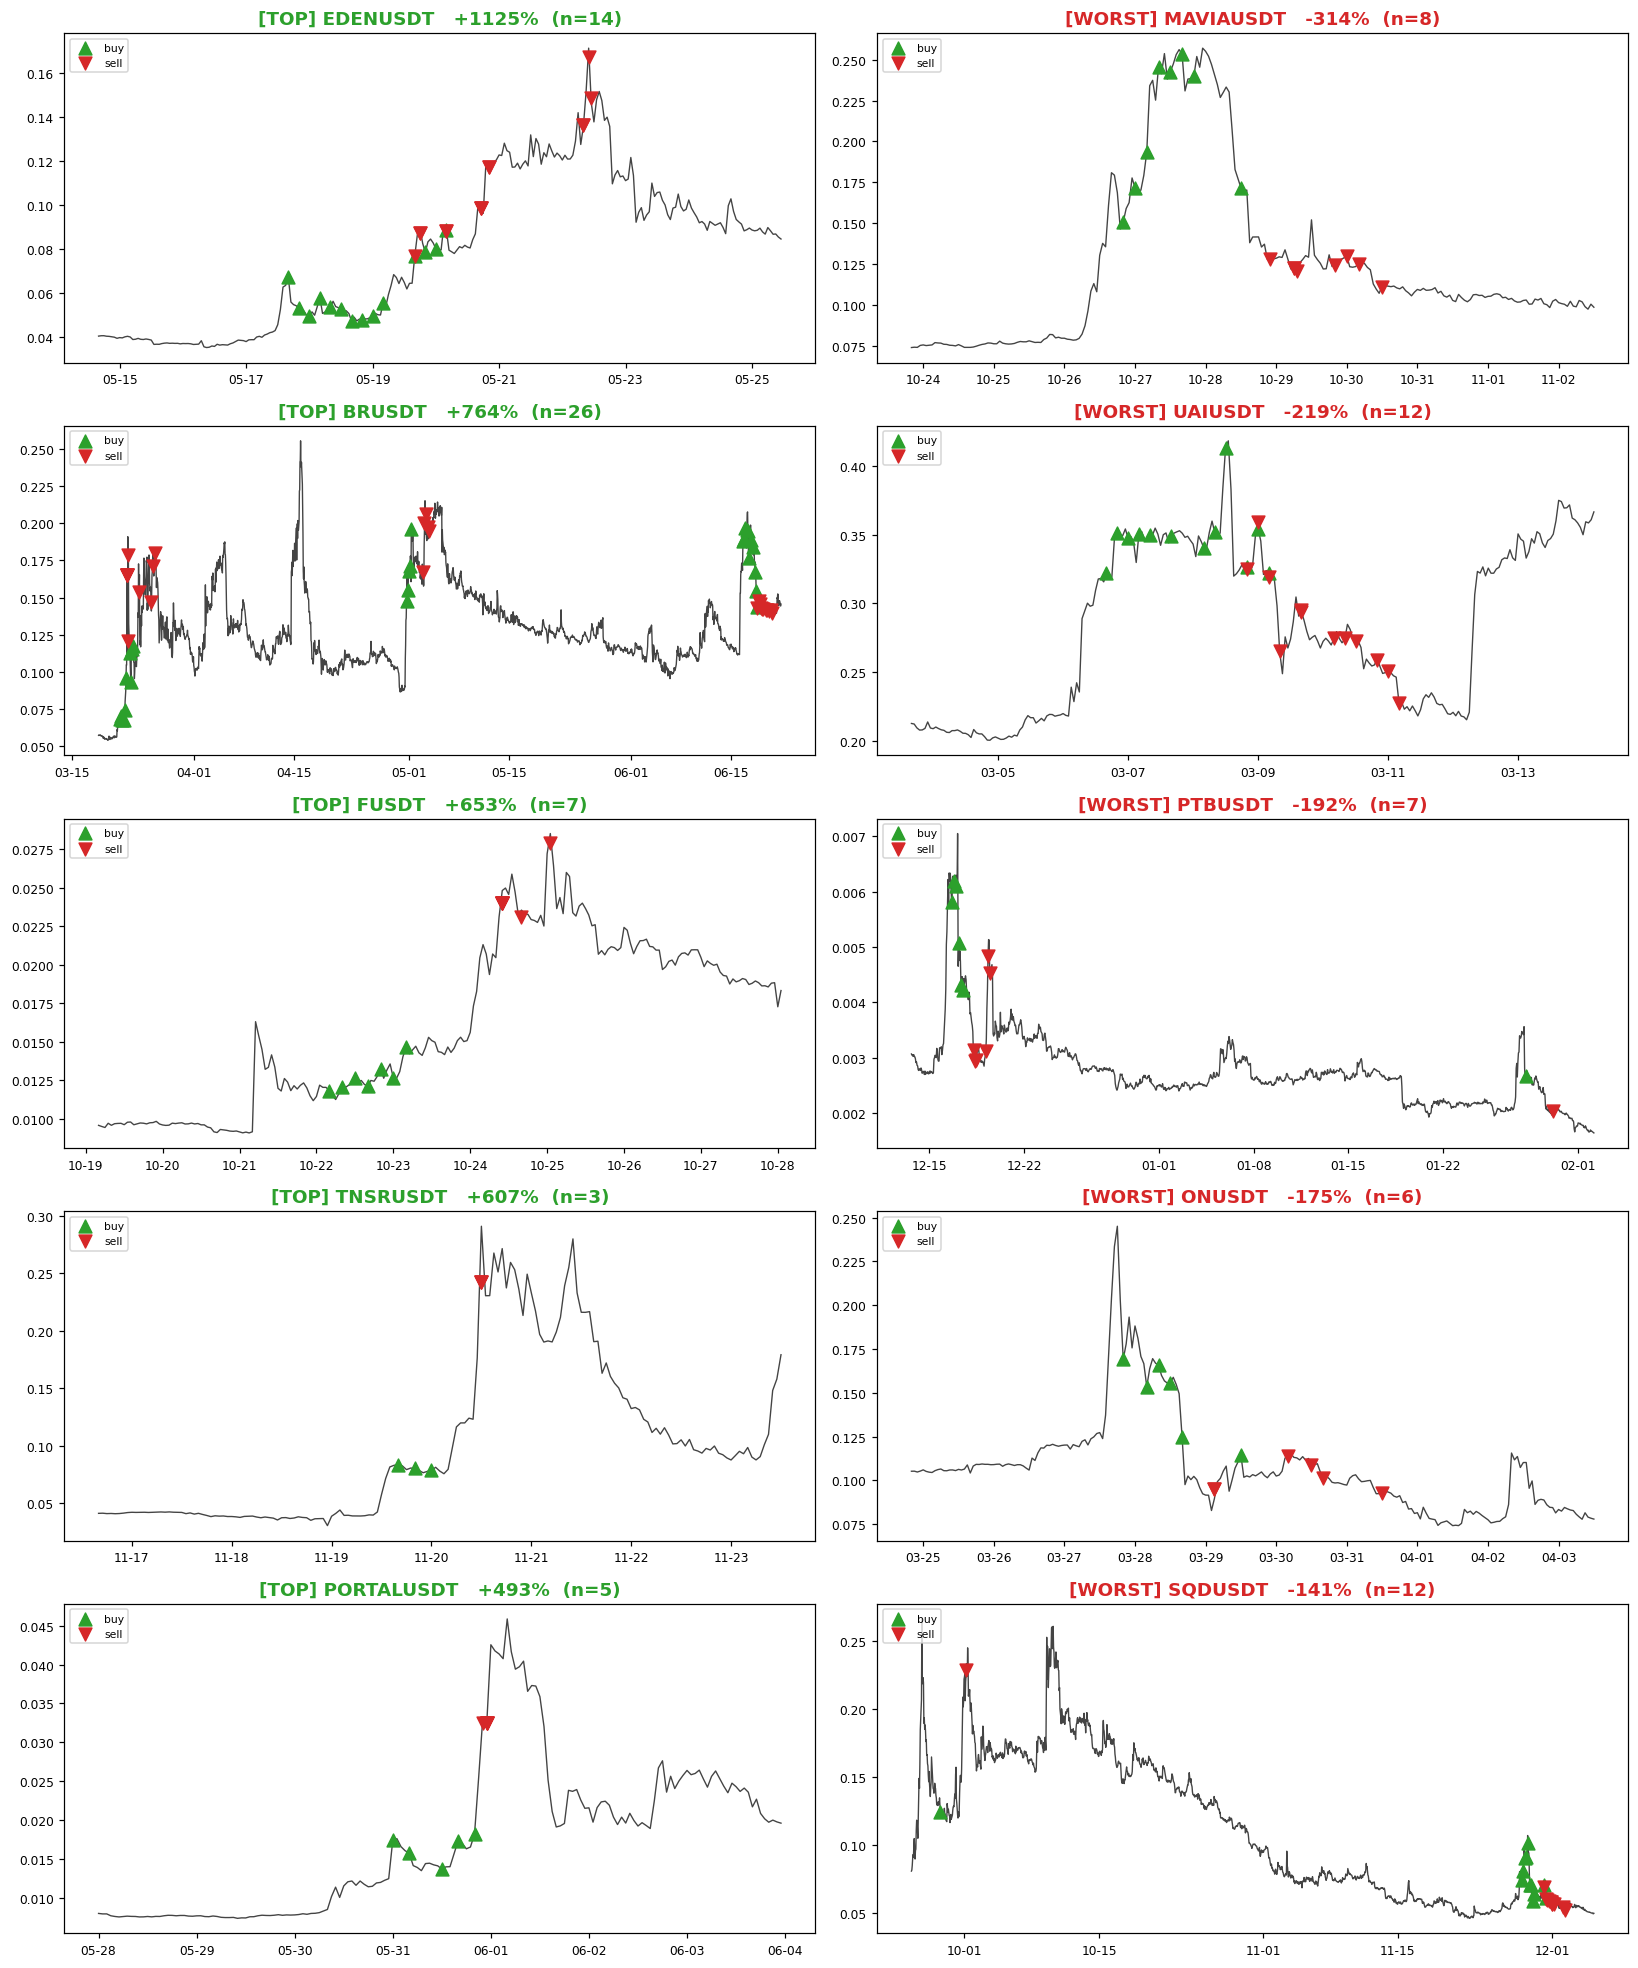

In [11]:
by_sym = t.groupby("symbol")["ret_final"].agg(["sum","count"]).sort_values("sum")
worst5 = by_sym.head(5).index.tolist()
top5   = by_sym.tail(5).index.tolist()[::-1]
picks = [("TOP", s) for s in top5] + [("WORST", s) for s in worst5]
print("TOP-5  :", [f"{s} {by_sym.loc[s,'sum']*100:+.0f}% (n{int(by_sym.loc[s,'count'])})" for s in top5])
print("WORST-5:", [f"{s} {by_sym.loc[s,'sum']*100:+.0f}% (n{int(by_sym.loc[s,'count'])})" for s in worst5])

fig, axes = plt.subplots(5,2, figsize=(15,18)); axes = axes.ravel()
# left column = top, right column = worst (interleave for 5x2 grid)
layout = []
for i in range(5): layout += [("TOP",top5[i]),("WORST",worst5[i])]
for ax,(grp,s) in zip(axes, layout):
    tt = t[t["symbol"]==s].sort_values("entry_ts")
    df = pd.read_parquet(f"{BARS}/{s}_binance_futures.parquet", engine="fastparquet")
    df["ts"] = pd.to_datetime(df["ts"], utc=True); df = df.sort_values("ts")
    lo = tt["entry_ts"].min()-pd.Timedelta(days=3); hi = tt["exit_ts"].max()+pd.Timedelta(days=3)
    w = df[(df["ts"]>=lo)&(df["ts"]<=hi)]
    ax.plot(w["ts"], w["close"], color="#444", lw=0.9)
    ax.scatter(tt["entry_ts"], tt["entry_close"], marker="^", c="#2ca02c", s=70, zorder=5, label="buy")
    exit_px = tt["entry_close"]*(1+tt["exit_ret"])
    ax.scatter(tt["exit_ts"], exit_px, marker="v", c="#d62728", s=70, zorder=5, label="sell")
    tot = by_sym.loc[s,"sum"]*100
    ax.set_title(f"[{grp}] {s}   {tot:+.0f}%  (n={len(tt)})", fontweight="bold",
                 color="#2ca02c" if grp=="TOP" else "#d62728")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d")); ax.tick_params(labelsize=8)
    ax.legend(fontsize=7, loc="upper left")
plt.tight_layout(); plt.show()

## 11 · Why peak120 is in production + provenance

**vs peak150 (retired):** +45–60% trades/day at equal mean return and **higher Sharpe** (grid max),
beating prod on the majority of seeds with fresh-seed Δ ≥ selection Δ (anti-overfit). The one genuine
cost — deeper drawdown — was narrowed by the `dud_thr 0.15→0.25` resweep (used in this backtest) and
by the unmodelled `h_value_exit`.

**perp features — REJECTED for peak120** (`experiments/2026-06-18-perpv3-peak120-covalidation`): the
perpv3 lift that won on peak150 *inverts* on peak120 (4-seed median Δ −0.105 Sharpe). peak120 ships
**alone**, no perp features.

### Provenance
| item | value |
|---|---|
| deploy commit | `afcf769` (model + config: model_path→peak120, threshold 0.80→0.85) |
| prod sync (thdjpw20) | go-live **2026-06-17 23:18:30 UTC**, PID 2563675 (replaced peak150/1530938) |
| dud_thr 0.25 hot-reload | 2026-06-18 16:02 UTC (this backtest uses 0.25) |
| backtest run | `/home/jpei/peak120_prod_wf/` — `run_label_sweep.py` copy, 6 seeds, 15-mo WF |
| caveats | harness fits btc-mid (relative valid); `h_exit`/`liq` not priced; §6-10 use the median-Sharpe seed |

*Notebook generated 2026-06-20. Config & feature importances computed from the deployed artifact;
all performance figures computed from the fresh `/home/jpei/peak120_prod_wf/` walk-forward output.*